In [12]:
import sys
sys.path.append("..")

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

In [14]:
from src.data.fetch_data import load_all_raw
from src.data.preprocess import preprocess_all

raw = load_all_raw()
processed = preprocess_all(raw)

price_train = processed["TCS.NS"]["train"]
price_test  = processed["TCS.NS"]["test"]

INFO | Preprocessing HDFCBANK.NS …
INFO | Preprocessing ICICIBANK.NS …
INFO | Preprocessing TCS.NS …
INFO | Preprocessing INFY.NS …
INFO | Preprocessing SUNPHARMA.NS …
INFO | Preprocessing DRREDDY.NS …
INFO | Preprocessing HINDUNILVR.NS …
INFO | Preprocessing ITC.NS …
INFO | Preprocessing MARUTI.NS …
INFO | Preprocessing complete.


In [15]:
model = ARIMA(price_train, order=(5,1,0))
model_fit = model.fit()
forecast = model_fit.forecast(steps=len(price_test))

/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at 

In [17]:
forecast = pd.Series(
    forecast,
    index=price_test.index,
    name="Forecast"
)

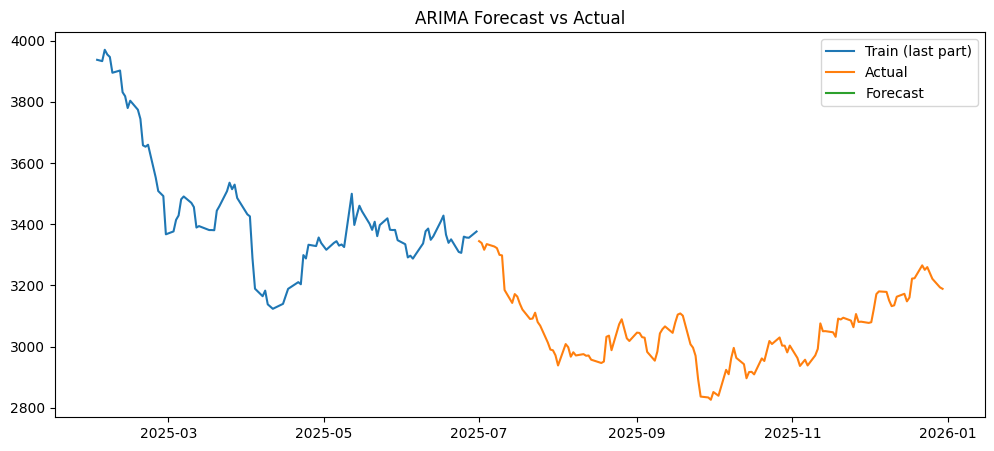

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(price_train[-100:], label="Train (last part)")
plt.plot(price_test, label="Actual")
plt.plot(forecast, label="Forecast")

plt.title("ARIMA Forecast vs Actual")
plt.legend()
plt.show()

In [25]:
price_test = price_test.dropna()
forecast = pd.Series(forecast, index=price_test.index)
forecast = forecast.dropna()

In [26]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(price_test, forecast))
mape = np.mean(np.abs((price_test - forecast) / price_test)) * 100

print("RMSE:", rmse)
print("MAPE:", mape)

ValueError: Found input variables with inconsistent numbers of samples: [125, 0]

In [27]:
print(len(price_train))
print(price_train.head())

1110
Date
2021-01-01    2569.267822
2021-01-04    2666.835693
2021-01-05    2713.820801
2021-01-06    2677.408203
2021-01-07    2661.000732
Name: Close, dtype: float64
